# Prva domača naloga pri predmetu ITAP

## Naloga 1 (20 točk): Učenje polinomskih modelov in regularizacija

V tej nalogi bomo raziskali, kako stopnja polinoma vpliva na prileganje polinomskega modela podatkom, ter spoznali regularizacijo Tihonova (angl. _ridge regression_) kot orodja za zmanjšanje nestabilnosti modelov.

**Za generiranje podatkov bomo uporabili polinom druge stopnje:** $y = 1 + 2x - x^2$ z dodanim šumom z Gaussovo porazdelitvijo $\mathcal{N}(0, \sigma), \sigma \approx 0{,}5$.

Podatke prebereš iz datoteke `dn1_e1.npz`, ki vsebuje 5 neodvisnih podatkovnih množic. Vsaka podatkovna množica v seznamu `datasets` je dvojica vektorjev `(x, y)`, kjer vektor `x` vsebuje vrednosti napovedne spremenljivke $x$, vektor `y` pa vrednosti ciljne spremenljivke $y$. Vsaka podatkovna množica vsebuje 7 primerov.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Naloži podatke
data = np.load('dn1_e1.npz')
datasets = [(data[f'x{i}'], data[f'y{i}']) for i in range(1, 6)]
print(f'Število podatkovnih množic: {len(datasets)}, število primerov v vsaki: {len(datasets[0][0])}')

Število podatkovnih množic: 5, število primerov v vsaki: 7


### 1.a (2 točke): Polinomske značilke

Dopolni definicijo funkcijo `polinomske_znacilke(x, d)`, ki sprejme vektor `x` vrednosti napovedne spremenljivke $x$ in stopnjo značilk `d` ter vrne matriko dimenzij $n \times (d+1)$ s stolpci $[1, \boldsymbol{x}, \boldsymbol{x}^2, \ldots, \boldsymbol{x}^d]$ (imenujemo jo tudi Vandermondova matrika), kjer je $n$ število primerov.

In [3]:
def polinomske_znacilke(x: np.ndarray, d: int) -> np.ndarray:
    """Za podan vektor x in podano stopnjo d vrne Vandermondovo matriko [1, x, x^2, ..., x^d]."""
    n = len(x)
    X = np.zeros((n, d + 1))
    for i in range(d + 1):
        X[:, i] = x ** i
    return X

In [4]:
# Preverjanje pravilnosti
x_test = np.array([0.0, 1.0, 2.0])
X_test = polinomske_znacilke(x_test, 3)

assert X_test.shape == (3, 4), f'Napačna oblika: {X_test.shape}, pričakovana (3, 4)'
assert np.allclose(X_test[0], [1, 0, 0, 0]), f'Napačna vrednost za x=0: {X_test[0]}'
assert np.allclose(X_test[1], [1, 1, 1, 1]), f'Napačna vrednost za x=1: {X_test[1]}'
assert np.allclose(X_test[2], [1, 2, 4, 8]), f'Napačna vrednost za x=2: {X_test[2]}'

print('Matrika za x=[0,1,2], d=3:')
print(X_test)

Matrika za x=[0,1,2], d=3:
[[1. 0. 0. 0.]
 [1. 1. 1. 1.]
 [1. 2. 4. 8.]]


### 1.b (7 točk): Točnost in splošnost polinomskih modelov različnih stopenj

Za vsako od petih podatkovnih množic poišči koeficiente polinomov stopenj 1 do 6. Za vsako stopnjo:
- razdeli podatke na učno (5 primerov) in testno množico (2 primera);
- izračunaj povprečno kvadratno napako (MSE) dobljenega polinoma na učni in testni množici.

Koeficiente polinoma izračunaj po formuli $\hat{\boldsymbol{\beta}} = (X^T X)^{-1} X^T \boldsymbol{y}$.

**Odgovori na vprašanja**

> _[Kakšna je stopnja polinoma, ki se najbolje prilega (a) učnim in (b) testnim podatkom?]_

Učnim podatkom se najbolje prilega polinom stopnje 6. Testnim podatkom se najbolje prilega polinom stopnje 2.

> _[Kaj opažaš pri visokih stopnjah polinoma?]_
Pri visokih stopnjah polinoma (npr. (d=4,5,6)) opaziš prenaučenost.

Učna napaka postane skoraj nič, ker model zelo natančno “zadene” učne točke.
Testna napaka pa pogosto naraste in je nestabilna.
Krivulja začne močno nihati (posebej na robovih intervala), zato so napovedi slabe za nove podatke.
To pomeni, da je model pri visokih stopnjah preveč kompleksen glede na malo število učnih primerov.

**Pri odgovorih na vprašanja v domači nalogi si pomagaj s tabelami in grafi.**

In [5]:
from sklearn.metrics import mean_squared_error

Dataset 1, Degree 1: Train error: 0.941859, Test error: 7.496728
Dataset 1, Degree 2: Train error: 0.054601, Test error: 0.903530
Dataset 1, Degree 3: Train error: 0.000459, Test error: 0.063226
Dataset 1, Degree 4: Train error: 0.000000, Test error: 0.016157
Dataset 1, Degree 5: Train error: 0.000000, Test error: 1.309076
Dataset 1, Degree 6: Train error: 0.000000, Test error: 0.219174
Dataset 2, Degree 1: Train error: 0.468217, Test error: 2.795677
Dataset 2, Degree 2: Train error: 0.063274, Test error: 0.854343
Dataset 2, Degree 3: Train error: 0.055945, Test error: 2.400750
Dataset 2, Degree 4: Train error: 0.000000, Test error: 13490216.012249
Dataset 2, Degree 5: Train error: 0.000000, Test error: 37116.941929
Dataset 2, Degree 6: Train error: 0.000000, Test error: 960562.811219
Dataset 3, Degree 1: Train error: 1.393807, Test error: 1.056820
Dataset 3, Degree 2: Train error: 0.002645, Test error: 0.449446
Dataset 3, Degree 3: Train error: 0.002542, Test error: 0.461818
Dataset 3

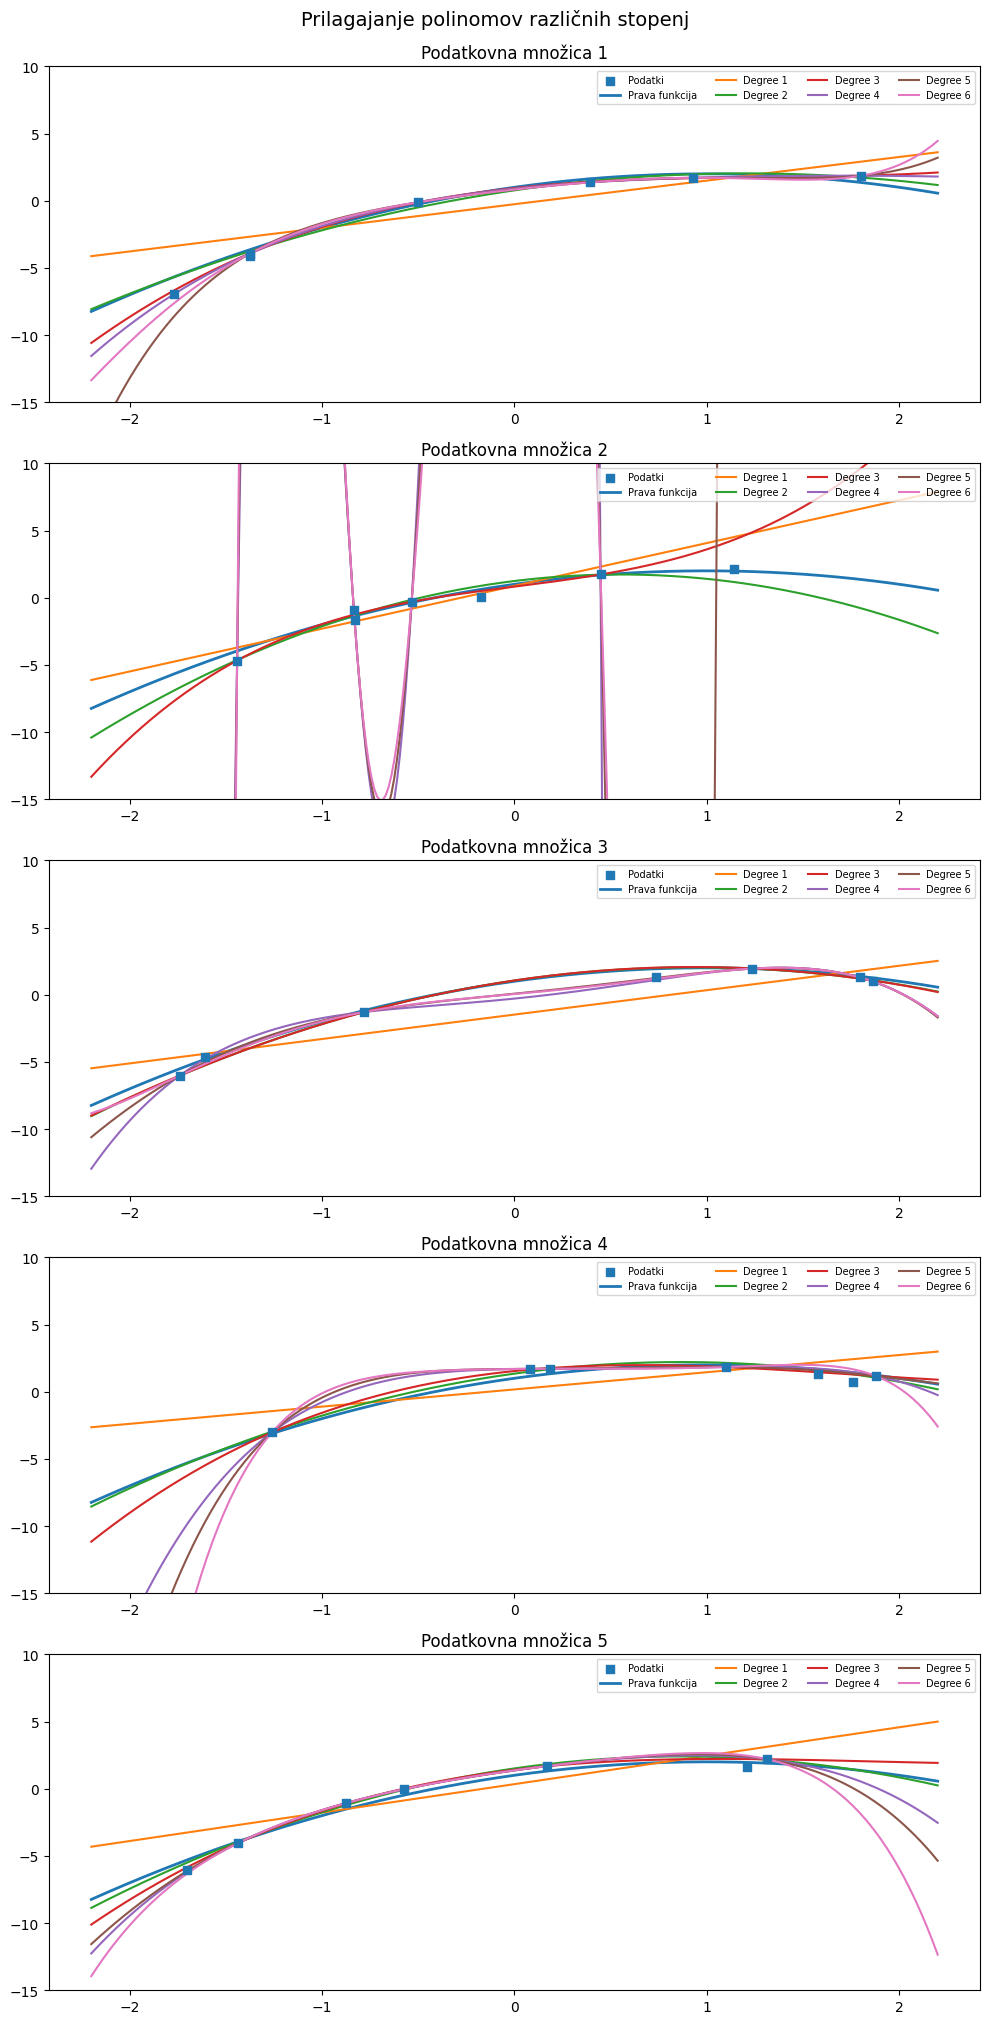

In [6]:
def najdi_koeficiente(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Izračuna koeficiente linearne regresije po formuli (X^T X)^{-1} X^T y."""
    # Pri višjih stopnjah in malo učnih točkah je X^T X lahko singularna,
    # zato uporabimo psevdo-inverz za numerično stabilnost.
    return np.linalg.pinv(X.T @ X) @ X.T @ y


def napovej(data: np.ndarray, beta: np.ndarray) -> np.ndarray:
    """Napove vrednost polinoma na podatke glede koeficiente beta."""
    return data @ beta


degrees = list(range(1, 7))

fig, axes = plt.subplots(5, 1, figsize=(10, 20))
x_plot = np.linspace(-2.2, 2.2, 300)

all_train_mse = []  # oblika (5 podatkovnih množic, 6 stopenj)
all_test_mse = []

for i, (x, y) in enumerate(datasets):
    # Razdelitev na učno in testno množico (5 učnih, 2 testna primera)
    x_train, y_train = x[:5], y[:5]
    x_test, y_test = x[5:], y[5:]

    train_mses = []
    test_mses = []

    ax = axes[i]
    ax.scatter(x, y, zorder=5, label='Podatki', marker='s')
    x_true = np.linspace(-2.2, 2.2, 300)
    ax.plot(x_true, 1 + 2 * x_true - x_true**2, label='Prava funkcija', linewidth=2)

    for d in degrees:
        # Izračun koeficientov in napak na učni/testni množici
        X_train = polinomske_znacilke(x_train, d)
        X_test = polinomske_znacilke(x_test, d)
        X_true = polinomske_znacilke(x_true, d)

        beta = najdi_koeficiente(X_train, y_train)

        pred_train = napovej(X_train, beta)
        pred_test = napovej(X_test, beta)
        pred_true = napovej(X_true, beta)

        train_error = mean_squared_error(y_train, pred_train)
        test_error = mean_squared_error(y_test, pred_test)

        train_mses.append(train_error)
        test_mses.append(test_error)
        print(f'Dataset {i+1}, Degree {d}: Train error: {train_error:.6f}, Test error: {test_error:.6f}')
        ax.plot(x_true, pred_true, label=f'Degree {d}')

    all_train_mse.append(train_mses)
    all_test_mse.append(test_mses)

    ax.set_ylim(-15, 10)
    ax.set_title(f'Podatkovna množica {i+1}')
    ax.legend(loc='upper right', fontsize=7, ncol=4)

plt.tight_layout()
plt.suptitle('Prilagajanje polinomov različnih stopenj', y=1.01, fontsize=14)
plt.show()

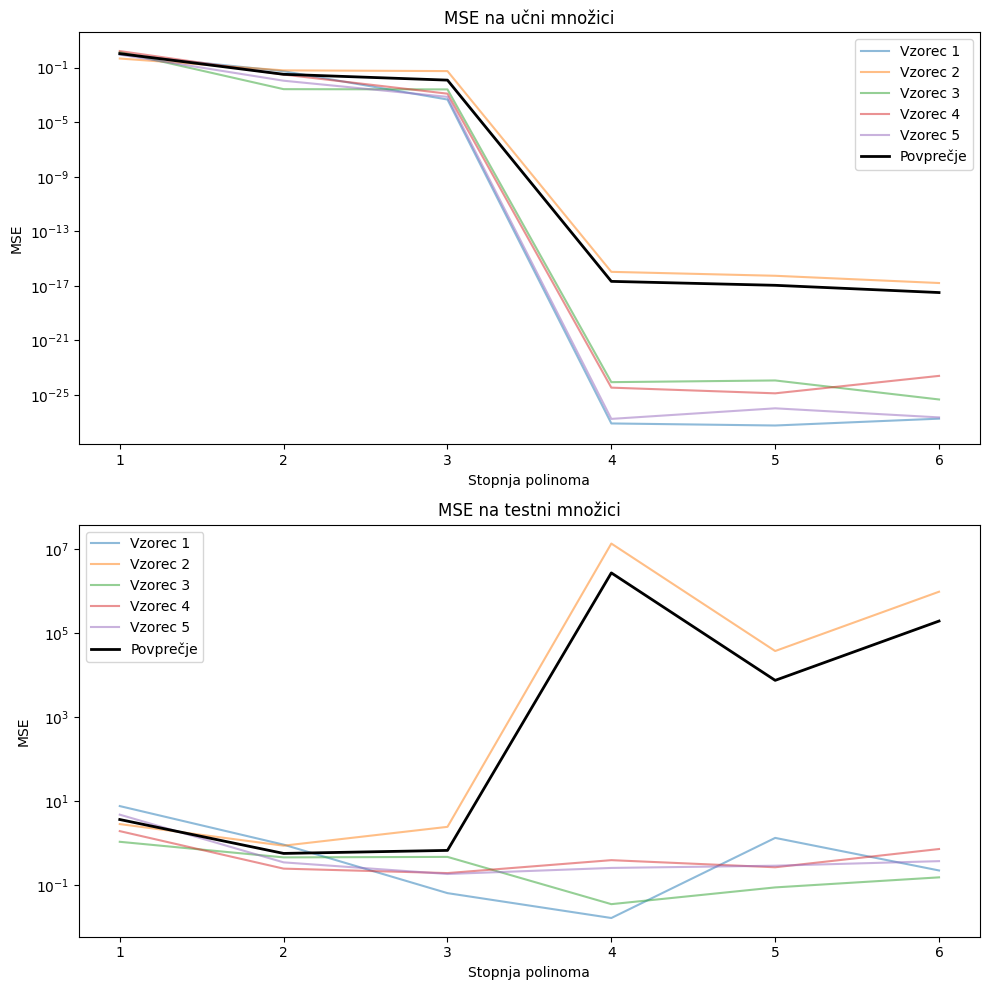

Najboljša stopnja polinoma po učnem MSE (povprečje): 6
Najboljša stopnja polinoma po testnem MSE (povprečje): 2


In [7]:
# Graf MSE glede na stopnjo polinoma (povprečje čez 5 podatkovnih množic)
all_train_mse = np.array(all_train_mse)  # (5, 6)
all_test_mse = np.array(all_test_mse)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

for i in range(5):
    ax1.plot(degrees, all_train_mse[i], alpha=0.5, label=f'Vzorec {i+1}')
ax1.plot(degrees, all_train_mse.mean(axis=0), 'k-', linewidth=2, label='Povprečje')
ax1.set_xlabel('Stopnja polinoma')
ax1.set_ylabel('MSE')
ax1.set_title('MSE na učni množici')
ax1.legend()
ax1.set_yscale('log')

for i in range(5):
    ax2.plot(degrees, all_test_mse[i], alpha=0.5, label=f'Vzorec {i+1}')
ax2.plot(degrees, all_test_mse.mean(axis=0), 'k-', linewidth=2, label='Povprečje')
ax2.set_xlabel('Stopnja polinoma')
ax2.set_ylabel('MSE')
ax2.set_title('MSE na testni množici')
ax2.legend()
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

best_train_deg = degrees[int(np.argmin(all_train_mse.mean(axis=0)))]
best_test_deg = degrees[int(np.argmin(all_test_mse.mean(axis=0)))]
print(f'Najboljša stopnja polinoma po učnem MSE (povprečje): {best_train_deg}')
print(f'Najboljša stopnja polinoma po testnem MSE (povprečje): {best_test_deg}')

**Odgovori na vprašanja**

> _Najboljša stopnja po učnem MSE (povprečje čez 5 množic) je **d = 6**; pri višjih stopnjah (od približno d=4 naprej) je učna napaka praktično 0. Najboljša stopnja po testnem MSE (povprečje) je **d = 2**._

> _[Ali se ta ujema s stopnjo 2 polinoma s katerim smo generirali podatke?]_

Da, ujema se za testne podatke.

Podatki so bili generirani s polinomom stopnje 2.
Najboljša stopnja po testnem MSE je tudi 2.
Po učnem MSE je sicer najboljša višja stopnja (6), kar je posledica prenaučenosti.
> _[Kaj se zgodi pri polinomih visokih stopenj, npr. $d=4,5,6$?]_

Pri visokih stopnjah (d=4,5,6) pride do prenaučenosti:

-model skoraj popolno prilega učne točke (učni MSE je skoraj 0),

-krivulja začne močno nihati, posebej na robovih intervala,

-koeficienti postanejo veliki in nestabilni,

-napovedi na testnih podatkih so slabše in zelo občutljive na majhne spremembe podatkov.

Zato višja stopnja tukaj ne pomeni boljšega modela za posploševanje.

### 1.c (4 točke): Stabilnost vrednosti koeficientov pri spremembi učnih podatkov

Nastavi stopnjo polinoma na $d = 3$ in $d = 5$ in izračunaj vrednosti njegovih koeficientov iz vsake od petih podatkovnih množic. Izpiši vrednosti koeficientov za vsako podatkovno množico in izračunaj varianco vsakega koeficienta čez pet podatkovnih množic.

**Odgovori na vprašanji**
> _[Je bolj stabilen polinom stopnje $d = 3$ ali $d = 5$?]_

> _[Kaj pomeni nestabilnost koeficientov za napovedi?]_

In [8]:
for d_fixed in [3, 5]:
    koeficienti = []

    header = f'{"":>26}' + ''.join(f'  β_{j:<4}' for j in range(d_fixed + 1))
    print(f'Koeficienti polinoma stopnje d={d_fixed}:')
    print(header)

    for i, (x, y) in enumerate(datasets):
        # Koeficiente ocenimo na celotni posamezni podatkovni množici.
        X = polinomske_znacilke(x, d_fixed)
        beta = najdi_koeficiente(X, y)
        koeficienti.append(beta)
        print(f'  Podatkovna množica {i+1}:' + ''.join(f'{b:>8.2f}' for b in beta))

    koeficienti = np.array(koeficienti)  # (5, d_fixed+1)
    variance = np.var(koeficienti, axis=0)
    print(f' {"Varianca:":>22}' + ''.join(f'{v:>8.2f}' for v in variance))
    print(f' Povprečna varianca: {variance.mean():.4f}\n')

Koeficienti polinoma stopnje d=3:
                            β_0     β_1     β_2     β_3   
  Podatkovna množica 1:    0.98    1.50   -1.13    0.32
  Podatkovna množica 2:    0.83    1.66   -0.86    0.42
  Podatkovna množica 3:    0.76    1.79   -0.98    0.07
  Podatkovna množica 4:    1.56    1.42   -1.43    0.26
  Podatkovna množica 5:    1.35    1.49   -1.18    0.29
              Varianca:    0.10    0.02    0.04    0.01
 Povprečna varianca: 0.0410

Koeficienti polinoma stopnje d=5:
                            β_0     β_1     β_2     β_3     β_4     β_5   
  Podatkovna množica 1:    0.92    1.47   -0.98    0.38   -0.04   -0.02
  Podatkovna množica 2:    0.24    1.56    3.27    3.28   -2.92   -2.08
  Podatkovna množica 3:   -0.26    1.79    0.80   -0.20   -0.49    0.10
  Podatkovna množica 4:    1.86   -1.64    2.98    0.62   -2.87    1.00
  Podatkovna množica 5:    1.52    1.33   -2.48   -0.26    0.75    0.40
              Varianca:    0.61    1.64    4.95    1.69    2.27    1.09
 

**Odgovori na vprašanja**

> _Polinom stopnje **d=3** je bistveno bolj stabilen kot polinom stopnje **d=5**. Povprečna varianca koeficientov pri d=3 je približno **0.0410**, pri d=5 pa približno **2.0428**, kar pomeni veliko večjo občutljivost koeficientov pri višji stopnji._

> _Nestabilnost koeficientov pomeni, da že majhne spremembe učnih podatkov povzročijo velike spremembe v parametrih modela in zato tudi v napovedih. Posledica so manj zanesljive napovedi in slabša posplošitev (večja verjetnost prenaučenosti)._

### 1.d (3 točke): Regularizirana regresija (Tikhonov / Ridge)

Dopolni funkcijo `najdi_koeficiente_reg(X, y, lambda_val)`, ki izračuna regularizirane koeficiente po formuli:

$$\hat{\boldsymbol{\beta}}_{\text{ridge}} = (X^T X + \lambda I)^{-1} X^T \boldsymbol{y} ,$$

kjer $X$ že vsebuje stolpec enic (ki bo našemu polinomu dodal vrednost začetne vrednosti), dimenzija enotske matrike $I$ pa mora ustrezati obliki matrike $X^T X$. Namig: Enotsko matriko $I$ lahko zgeneriraš s funkcijo `np.eye`.

In [9]:
def najdi_koeficiente_reg(X: np.ndarray, y: np.ndarray, lambda_val: float = 1e-8) -> np.ndarray:
    """Izračuna regularizirane koeficiente: (X^T X + lambda * I)^{-1} X^T y."""
    I = np.eye(X.shape[1])
    return np.linalg.inv(X.T @ X + lambda_val * I) @ X.T @ y

In [10]:
# Preverjanje pravilnosti (z majhnim lambda mora dati podoben rezultat kot brez regularizacije)
np.random.seed(0)
x_chk = np.random.uniform(-1, 1, 50)
y_chk = 3 + 1.5 * x_chk - 0.8 * x_chk**2 + np.random.normal(0, 0.1, 50)
X_chk = polinomske_znacilke(x_chk, 2)

coefs_reg = najdi_koeficiente_reg(X_chk, y_chk, lambda_val=1e-8)
coefs_plain = najdi_koeficiente(X_chk, y_chk)

assert coefs_reg.shape == (3,), f'Napačna oblika koeficientov: {coefs_reg.shape}'
assert np.allclose(coefs_reg, coefs_plain, atol=1e-3), \
    f'Z majhnim lambda mora biti rezultat podoben neregulariziranemu: {coefs_reg} vs {coefs_plain}'
print('Preverjanje uspešno!')
print(f'Regularizirani koeficienti (λ=1e-8): {coefs_reg}')
print(f'Neregularizirani koeficienti:        {coefs_plain}')

Preverjanje uspešno!
Regularizirani koeficienti (λ=1e-8): [ 2.99203325  1.48415879 -0.82673456]
Neregularizirani koeficienti:        [ 2.99203325  1.48415879 -0.82673456]


### 1.e (4 točke): Vpliv vrednosti λ na stabilnost in napako polinomskih modelov

Ponovi eksperiment iz naloge 1.c s funkcijo (`najdi_koeficiente_reg`) za različne vrednosti λ.

Za vsak λ iz nabora `[1e-8, 1e-4, 1e-2, 1, 10]`:
- Prilagodi polinom stopnje $d = 6$ na vsaki od petih podatkovnih množic (učna množica: prvih 5 točk, testna množica: zadnji 2 točki)
- Izračunaj varianco vsakega koeficienta čez pet podatkovnih množic in poročaj povprečno varianco čez vse koeficiente
- Izračunaj povprečni MSE na učni in testni množici čez pet podatkovnih množic

**Odgovori na vprašanja**

> _[Kako vrednost λ vpliva na stabilnost koeficientov?]_

> _[Kako vrednost λ vpliva na napako na učni in testni množici?]_

> _[Pri kateri vrednosti λ je testna napaka najmanjša? Ali se to ujema z območjem nizke variance?]_

> _[Ali obstaja kompromis med stabilnostjo in napako (točnostjo) polinomskega modela? Kaj se zgodi pri zelo majhnih in zelo velikih vrednostih λ?]_

Rezultati za polinom stopnje d=6:
         λ     Povpr. varianca   Povpr. MSE (učna)   Povpr. MSE (testna)
------------------------------------------------------------------------
     1e-08        11561.135252            0.000004         185088.111026
     1e-04            0.447876            0.011070              3.526575
     1e-02            0.123758            0.011387              0.587875
     1e+00            0.039891            0.166042              5.147463
     1e+01            0.004622            0.675174              4.102988


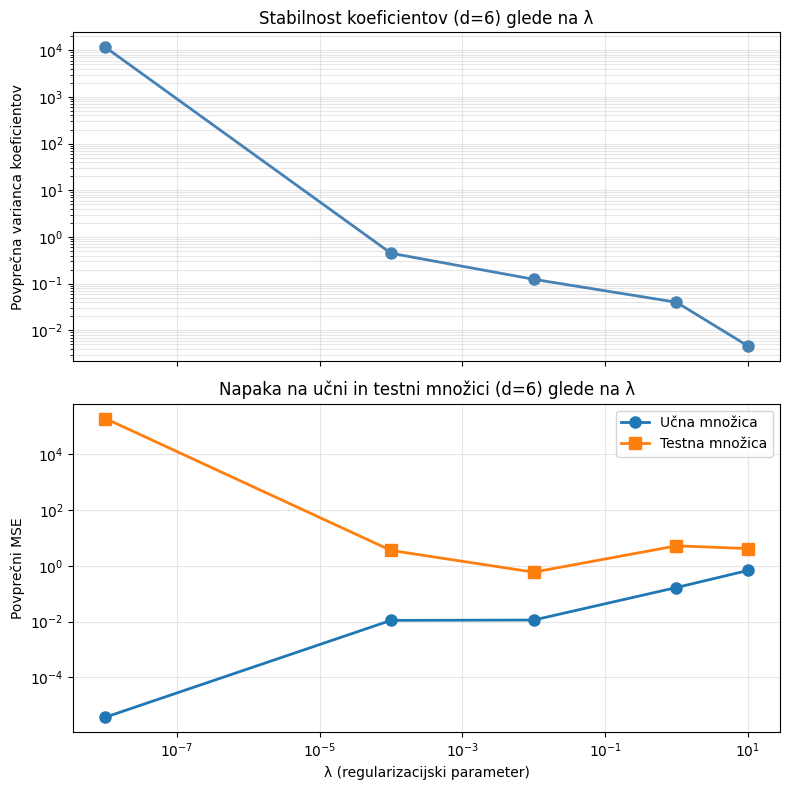


Optimalna vrednost λ za testni MSE: 1e-02


In [11]:
lambda_values = [1e-8, 1e-4, 1e-2, 1, 10]
d_fixed = 6

mean_variances = []
mean_train_mse = []
mean_test_mse = []

print(f'Rezultati za polinom stopnje d={d_fixed}:')
print(f'{"λ":>10}  {"Povpr. varianca":>18}  {"Povpr. MSE (učna)":>18}  {"Povpr. MSE (testna)":>20}')
print('-' * 72)

for lam in lambda_values:
    koeficienti = []
    train_mses = []
    test_mses = []

    for x, y in datasets:
        x_train = x[:5]
        y_train = y[:5]
        x_test = x[5:]
        y_test = y[5:]

        X_train = polinomske_znacilke(x_train, d_fixed)
        beta = najdi_koeficiente_reg(X_train, y_train, lambda_val=lam)
        koeficienti.append(beta)

        train_mses.append(mean_squared_error(y_train, napovej(X_train, beta)))
        test_mses.append(mean_squared_error(y_test, napovej(polinomske_znacilke(x_test, d_fixed), beta)))

    var_mean = np.var(np.array(koeficienti), axis=0).mean()
    mean_variances.append(var_mean)
    mean_train_mse.append(np.mean(train_mses))
    mean_test_mse.append(np.mean(test_mses))
    print(f'{lam:>10.0e}  {var_mean:>18.6f}  {np.mean(train_mses):>18.6f}  {np.mean(test_mses):>20.6f}')

# Grafa
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

ax1.plot(lambda_values, mean_variances, 'o-', color='steelblue', linewidth=2, markersize=8)
ax1.set_ylabel('Povprečna varianca koeficientov')
ax1.set_title(f'Stabilnost koeficientov (d={d_fixed}) glede na λ')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.grid(True, which='both', alpha=0.3)

ax2.plot(lambda_values, mean_train_mse, 'o-', color='tab:blue', linewidth=2, markersize=8, label='Učna množica')
ax2.plot(lambda_values, mean_test_mse, 's-', color='tab:orange', linewidth=2, markersize=8, label='Testna množica')
ax2.set_xlabel('λ (regularizacijski parameter)')
ax2.set_ylabel('Povprečni MSE')
ax2.set_title(f'Napaka na učni in testni množici (d={d_fixed}) glede na λ')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.legend()
ax2.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

best_lam = lambda_values[int(np.argmin(mean_test_mse))]
print(f'\nOptimalna vrednost λ za testni MSE: {best_lam:.0e}')

**Odgovori na vprašanja**

> _Z večanjem λ se stabilnost koeficientov povečuje (povprečna varianca koeficientov pada). Pri zelo majhnem λ=1e-8 je varianca zelo velika (~11561), nato pa z rastjo λ močno upade (do ~0.0046 pri λ=10)._ 

> _Z večanjem λ učna napaka praviloma narašča (model je bolj omejen). Testna napaka je velika pri premajhnem λ (prenaučenost), nato pade do minimuma pri srednji regularizaciji, pri prevelikem λ pa spet naraste (prevelika pristranskost / podučenost)._ 

> _Najmanjša testna napaka je pri **λ = 1e-2** (povprečni testni MSE ~0.588). To se delno ujema z območjem nižje variance: varianca je tam že bistveno manjša kot pri λ=1e-8 in 1e-4, vendar absolutno najmanjša varianca (pri λ=10) ne da najboljše testne napake._

> _Da, obstaja jasen kompromis med stabilnostjo in točnostjo. Pri zelo majhnem λ je model nestabilen in prenaučen (zelo nizka učna napaka, zelo visoka testna napaka). Pri zelo velikem λ so koeficienti stabilni, a model preveč zglajen in podučen (učna in pogosto tudi testna napaka sta višji). Najboljši rezultat je pri zmerni regularizaciji._

## Naloga 2 (10 točk): Klasifikacija tumorjev dojke

Analiziraj podatke iz datoteke `dn1_e2.npz` in sestavi napovedni model, ki bo čim boljše napovedal, ali je tumor maligni ali benigni. Poskrbi, da poleg ocene zmogljivosti modela poročaš tudi o **stabilnosti ocene njegove zmogljivosti** (npr. s prečnim preverjanjem). Opiši tvoj izbrani model ter kako in zakaj si se odločal/a pri vsakem vidiku njegove izbire. Opiši tudi ostale modele, ki si jih poskusil/a, a jih nisi izbral/a, ker niso dosegali zmogljivosti izbranega modela.

Lahko izbiraš med linearnimi modeli, modeli najbližjih sosedov in odločitvenimi drevesi. Kot mero zmogljivosti lahko uporabiš poljubno mero za zmogljivost modelov za binarno (dvojiško) klasifikacijo, ki smo jih obravnavali na predavanjih in vajah. Obrazloži svojo izbiro mere zmogljivosti na osnovi katere boš izbiral/a najboljši model.

Podatkovna množica vsebuje 569 primerov in 30 napovednih spremenljivk, pridobljenih iz slik celic tumorja. Pomen napovednih spremenljivk je sledeč (vsaka od desetih osnovnih mer naštetih pod tabelo je podana s tremi spremenljivkami, povprečje, standardna napaka in najslabša vrednost):

| Indeks | Agregatna funkcija | Opis |
|--------|----------|------|
| 0–9 | Povprečje | Povprečna vrednost mere čez jedra v primeru |
| 10–19 | Standardna napaka | Standardna napaka mere |
| 20–29 | Najslabša vrednost | Povprečje treh največjih vrednosti mere |

Deset osnovnih mer: polmer jedra, tekstura, obseg, površina, gladkost, kompaktnost, konkavnost, konkavne točke, simetrija in fraktalna dimenzija.

In še pomen vrednosti ciljne spremenljivke je:
- $y = 0$: maligni tumor in
- $y = 1$: benigni tumor.

In [3]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    GridSearchCV,
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_validate,
)
from sklearn.metrics import make_scorer, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# -----------------------------
# 1) Nalaganje podatkov
# -----------------------------
data = np.load("dn1_e2.npz")
X = data["X"]
y = data["y"]

print(f"Oblika X: {X.shape}, oblika y: {y.shape}")
print(f"Delež benignih (y=1): {y.mean():.3f}, delež malignih (y=0): {(1 - y.mean()):.3f}")

# Metrika: F1 za razred y=0 (maligni) - želimo dobro zaznati maligne primere,
# hkrati pa kaznovati tako lažne negative kot lažne pozitive.
scorer = make_scorer(f1_score, pos_label=0)

# Zunanje CV za oceno stabilnosti in generalizacije (manjša kompleksnost za hitrejši izračun).
outer_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)
# Notranje CV za izbiro hiperparametrov.
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# -----------------------------
# 2) Kandidatni modeli in mreže
# -----------------------------
candidates = {
    "LogisticRegression": (
        Pipeline(
            [
                ("scaler", StandardScaler()),
                (
                    "clf",
                    LogisticRegression(
                        max_iter=2000,
                        solver="liblinear",
                        random_state=42,
                    ),
                ),
            ]
        ),
        {
            "clf__C": np.logspace(-2, 2, 5),
            "clf__penalty": ["l1", "l2"],
        },
    ),
    "KNN": (
        Pipeline(
            [
                ("scaler", StandardScaler()),
                ("clf", KNeighborsClassifier()),
            ]
        ),
        {
            "clf__n_neighbors": [3, 5, 7, 11, 15],
            "clf__weights": ["uniform", "distance"],
            "clf__p": [1, 2],
        },
    ),
    "DecisionTree": (
        Pipeline(
            [
                ("clf", DecisionTreeClassifier(random_state=42)),
            ]
        ),
        {
            "clf__max_depth": [3, 5, None],
            "clf__min_samples_split": [2, 10],
            "clf__min_samples_leaf": [1, 4],
            "clf__criterion": ["gini", "entropy"],
        },
    ),
}

# -----------------------------
# 3) Nested CV primerjava modelov
# -----------------------------
rows = []
for name, (pipe, param_grid) in candidates.items():
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring=scorer,
        cv=inner_cv,
        n_jobs=1,
        refit=True,
    )

    cv_res = cross_validate(
        gs,
        X,
        y,
        scoring=scorer,
        cv=outer_cv,
        n_jobs=-1,
        return_train_score=False,
    )

    test_scores = cv_res["test_score"]
    rows.append(
        {
            "model": name,
            "mean_f1_maligni": test_scores.mean(),
            "std_f1_maligni": test_scores.std(ddof=1),
            "min_f1_maligni": test_scores.min(),
            "max_f1_maligni": test_scores.max(),
        }
    )

results = pd.DataFrame(rows).sort_values(
    by=["mean_f1_maligni", "std_f1_maligni"],
    ascending=[False, True],
)

print("\n=== Primerjava modelov (nested CV, metrika F1 za maligni razred y=0) ===")
print(results.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

best_model_name = results.iloc[0]["model"]
print(f"\nIzbran model: {best_model_name}")

# -----------------------------
# 4) Končna nastavitev izbranega modela
# -----------------------------
best_pipe, best_grid = candidates[best_model_name]
final_gs = GridSearchCV(
    estimator=best_pipe,
    param_grid=best_grid,
    scoring=scorer,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=123),
    n_jobs=-1,
    refit=True,
)
final_gs.fit(X, y)

print("\n=== Najboljši hiperparametri izbranega modela (5-fold CV) ===")
print(final_gs.best_params_)
print(f"Najboljši CV F1 (maligni): {final_gs.best_score_:.4f}")

print("\n=== Kratek povzetek za poročilo ===")
print("- Izbira metrike: F1 za razred y=0 (maligni tumor), ker je ključno dobro zaznati maligne primere.")
print("- Stabilnost: ocenjena z nested CV (5x2 zunanjih delitev); poročana je povprečna vrednost in standardni odklon.")
print("- Izbrani model je tisti z najvišjim povprečnim F1 in hkrati nizko variabilnostjo med delitvami.")
print("- Ostali modeli (linearen / k-NN / drevo), ki imajo nižji povprečni F1 ali večjo nestabilnost, niso bili izbrani.")

Oblika X: (569, 30), oblika y: (569,)
Delež benignih (y=1): 0.627, delež malignih (y=0): 0.373

=== Primerjava modelov (nested CV, metrika F1 za maligni razred y=0) ===
             model  mean_f1_maligni  std_f1_maligni  min_f1_maligni  max_f1_maligni
LogisticRegression           0.9661          0.0175          0.9383          0.9882
               KNN           0.9562          0.0206          0.9268          0.9882
      DecisionTree           0.9065          0.0355          0.8205          0.9438

Izbran model: LogisticRegression

=== Najboljši hiperparametri izbranega modela (5-fold CV) ===
{'clf__C': np.float64(1.0), 'clf__penalty': 'l1'}
Najboljši CV F1 (maligni): 0.9692

=== Kratek povzetek za poročilo ===
- Izbira metrike: F1 za razred y=0 (maligni tumor), ker je ključno dobro zaznati maligne primere.
- Stabilnost: ocenjena z nested CV (5x2 zunanjih delitev); poročana je povprečna vrednost in standardni odklon.
- Izbrani model je tisti z najvišjim povprečnim F1 in hkrati nizko 